<a href="https://colab.research.google.com/github/sakthisowmiya123/-customer-churn-prediction/blob/main/kN_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

In [ ]:
#display first 5 records
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
#number of records in dataset
df.shape

(20640, 10)

In [ ]:
#features in dataset
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
#missing value in dats set
df.isnull()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
20635,False,False,False,False,False,False,False,False,False,False
20636,False,False,False,False,False,False,False,False,False,False
20637,False,False,False,False,False,False,False,False,False,False
20638,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
#to find the numerical column
df.dtypes.drop

<bound method Series.drop of longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object>

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Feature Selection
features=['longitude','latitude','housing_median_age','median_income',"median_house_value"]
x=df[features]

FEATURE SCALING

In [ ]:
scalar = StandardScaler()
x_scaled = scalar.fit_transform(x)

In [ ]:
x_scaled

array([[-1.32783522,  1.05254828,  0.98214266,  2.34476576,  2.12963148],
       [-1.32284391,  1.04318455, -0.60701891,  2.33223796,  1.31415614],
       [-1.33282653,  1.03850269,  1.85618152,  1.7826994 ,  1.25869341],
       ...,
       [-0.8237132 ,  1.77823747, -0.92485123, -1.14259331, -0.99274649],
       [-0.87362627,  1.77823747, -0.84539315, -1.05458292, -1.05860847],
       [-0.83369581,  1.75014627, -1.00430931, -0.78012947, -1.01787803]])

In [ ]:
pd.DataFrame(x_scaled)

,0,1,2,3,4
0,-1.327835,1.052548,0.982143,2.344766,2.129631
1,-1.322844,1.043185,-0.607019,2.332238,1.314156
2,-1.332827,1.038503,1.856182,1.782699,1.258693
3,-1.337818,1.038503,1.856182,0.932968,1.165100
4,-1.337818,1.038503,1.856182,-0.012881,1.172900
...,...,...,...,...,...
20635,-0.758826,1.801647,-0.289187,-1.216128,-1.115804
20636,-0.818722,1.806329,-0.845393,-0.691593,-1.124470
20637,-0.823713,1.778237,-0.924851,-1.142593,-0.992746
20638,-0.873626,1.778237,-0.845393,-1.054583,-1.058608


ELBOW METHOD

In [ ]:
WCSS = []
for i in range(1,11):
    model = KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=9)
    model.fit(x_scaled)
    WCSS.append(model.inertia_)


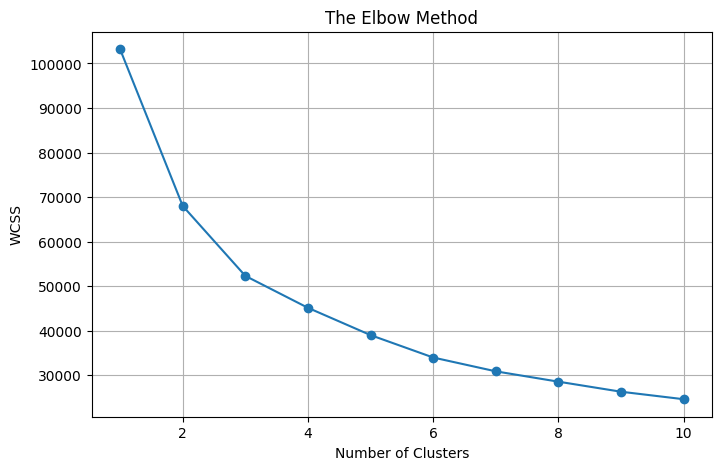

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), WCSS, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

SESSION 4 training kmeans

In [ ]:
optimalk = 6
model = KMeans(n_clusters=optimalk, init='k-means++', random_state=42, n_init=9)
# fit the model and predict clusters
cluster_label = model.fit_predict(x_scaled)
df[['total_rooms', 'households']]

,total_rooms,households
0,880.0,126.0
1,7099.0,1138.0
2,1467.0,177.0
3,1274.0,219.0
4,1627.0,259.0
...,...,...
20635,1665.0,330.0
20636,697.0,114.0
20637,2254.0,433.0
20638,1860.0,349.0


In [ ]:
df['cluster'] = cluster_label
silhouette_score(x_scaled,cluster_label)

np.float64(0.27771537576651073)